### Architecture 
This experiment has modulation on late stage with the frozen backbone, so the stage 8 values are modulated by FiLM parameters while before all stages are kept frozen

<br>
<br>

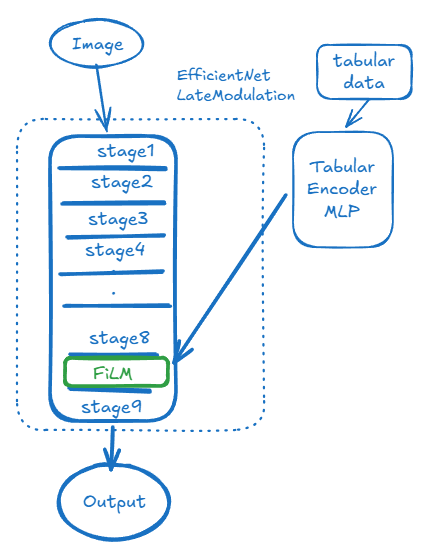



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra","exp12_film_effB1_strongAug384_BS12_identity", "exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_identity_init")  

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_identity_init"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]
cfg["img_size"] = 384
cfg["aug"] = "strong"
cfg["batch_size"] = 12

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=False,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    identity_init=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_identity_init: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=37.0057 | ValRMSE: 24.1204
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=25.5786 | ValRMSE: 24.7422
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=22.6565 | ValRMSE: 25.5613
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=22.0677 | ValRMSE: 25.1538
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=21.6750 | ValRMSE: 25.1981
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=21.5603 | ValRMSE: 24.8124
Early stopping at epoch 6
Fold 1 best RMSE: 24.1204

=== exp12_film_fusion_effB1_internal_late_modulation_freeze_backbone_identity_init: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=38.3120 | ValRMSE: 26.0986
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=27.5063 | ValRMSE: 22.1243
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=23.2887 | ValRMSE: 24.0609
Epoch 4/10 | Fold 2 | Train[MSE]: RMSE=22.0865 | ValRMSE: 24.0843
Epoch 5/10 | Fold 2 | Train[MSE]: RMSE=21.9299 | ValRMSE: 23.6805
Epoch 6/10 | Fold 2 | Train[MS

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 24.1204 (n=1983)
Fold 2 OOF RMSE: 22.1243 (n=1983)
Fold 3 OOF RMSE: 23.4840 (n=1982)
Fold 4 OOF RMSE: 22.9272 (n=1982)
Fold 5 OOF RMSE: 23.3245 (n=1982)


### Train and Validation RMSE Curve

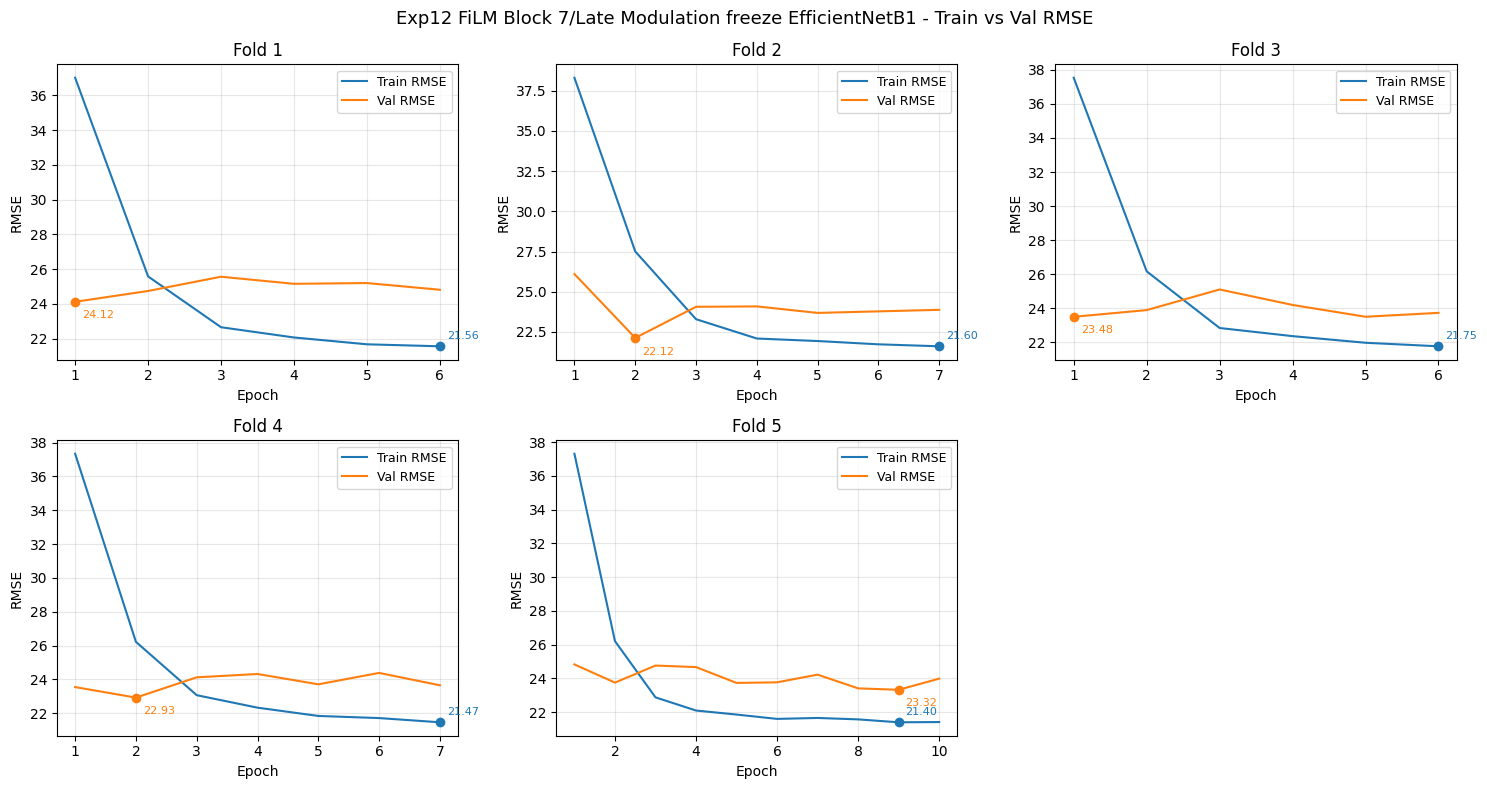

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block 7/Late Modulation freeze EfficientNetB1")

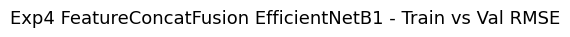

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

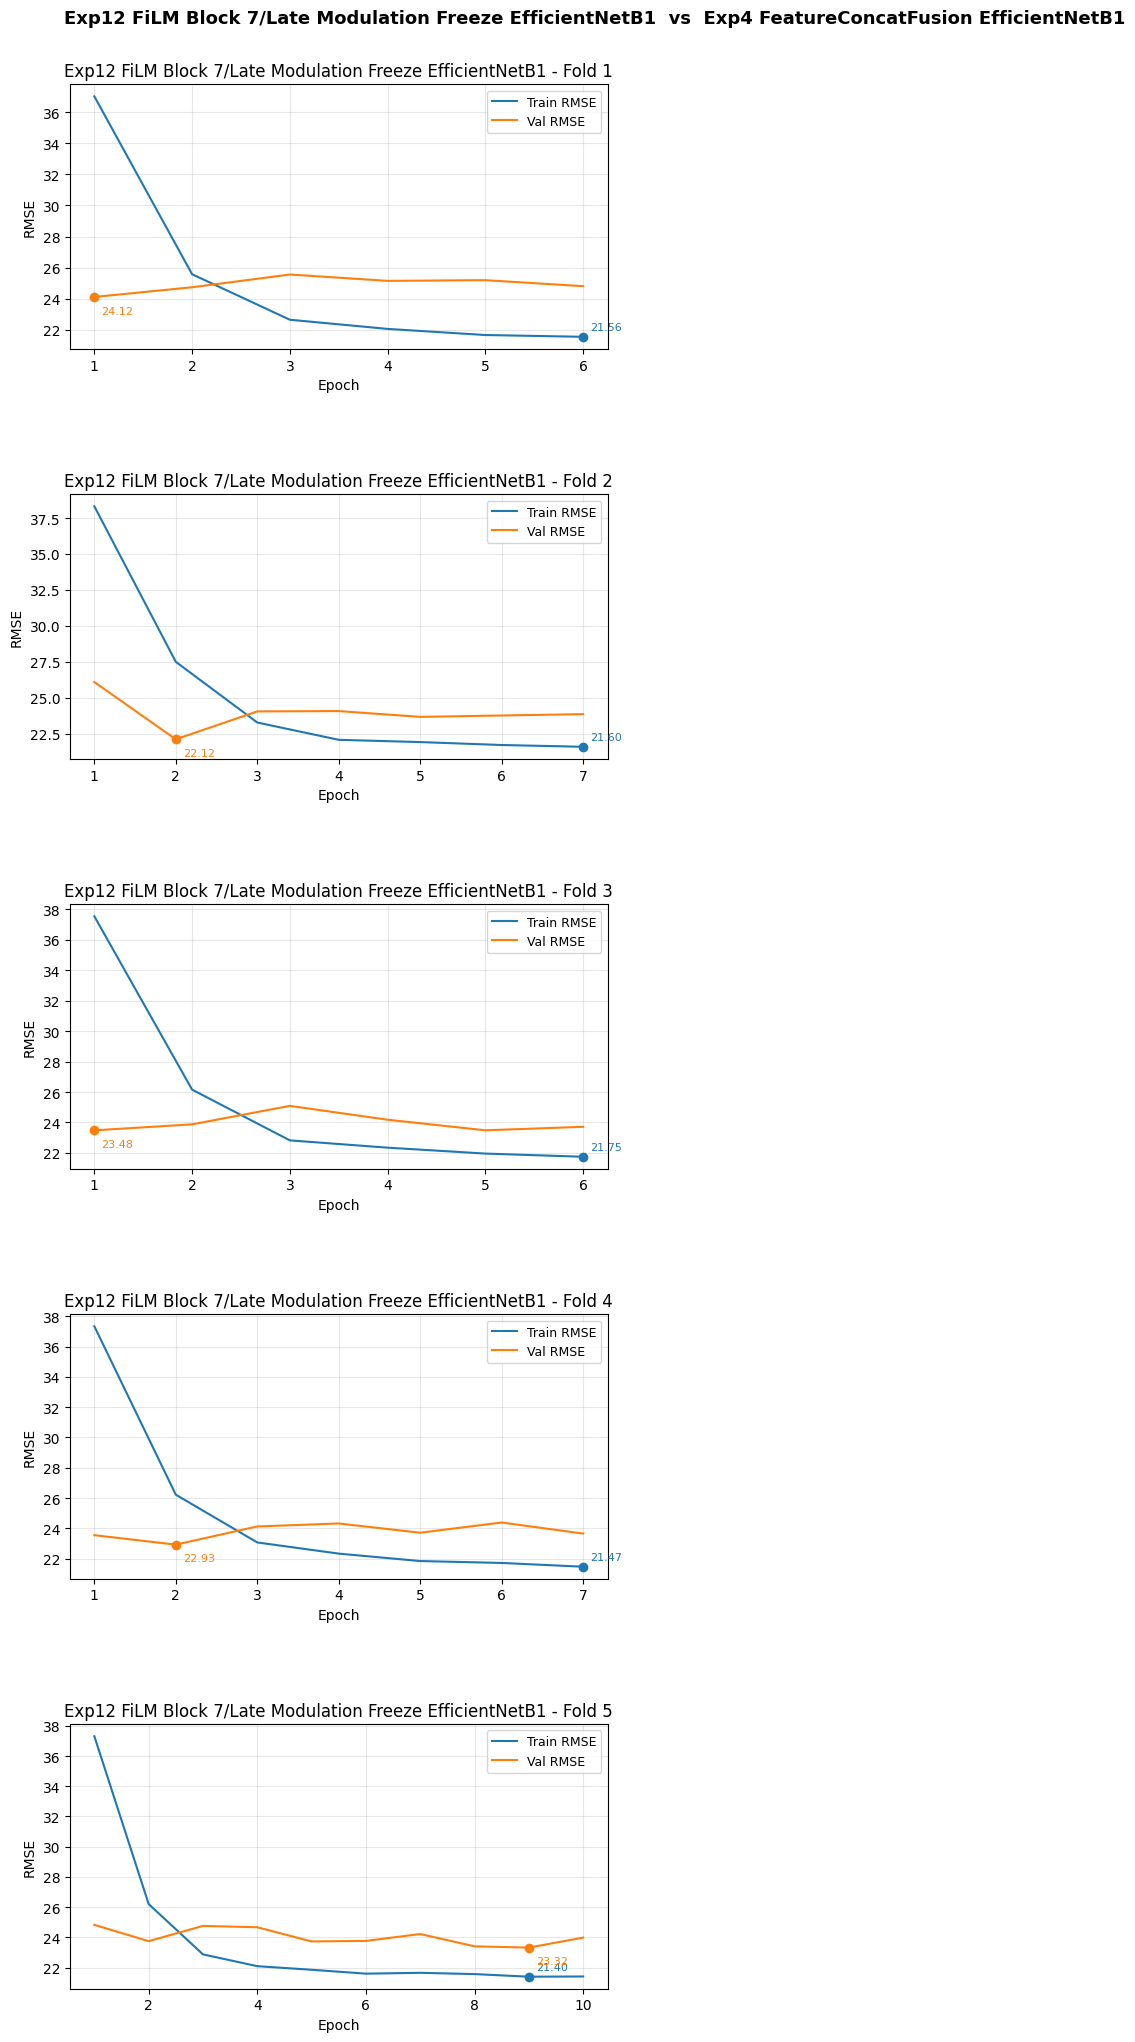

In [8]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM Block 7/Late Modulation Freeze EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [9]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,d82afe0c787d654fc4a7be069e8cba9b,1,100,13.872737,86.127263
1,eafe4e31237c5b6fd0957e80418c36b0,1,100,13.945653,86.054347
2,2114efb5473197ce31bcc75018c71660,1,100,15.363093,84.636907
3,0a3faad2084666073e567516f0cc3ae5,3,100,16.070616,83.929384
4,4e118e2f4cb952bba2fa4b3a842c2500,1,96,12.106091,83.893909


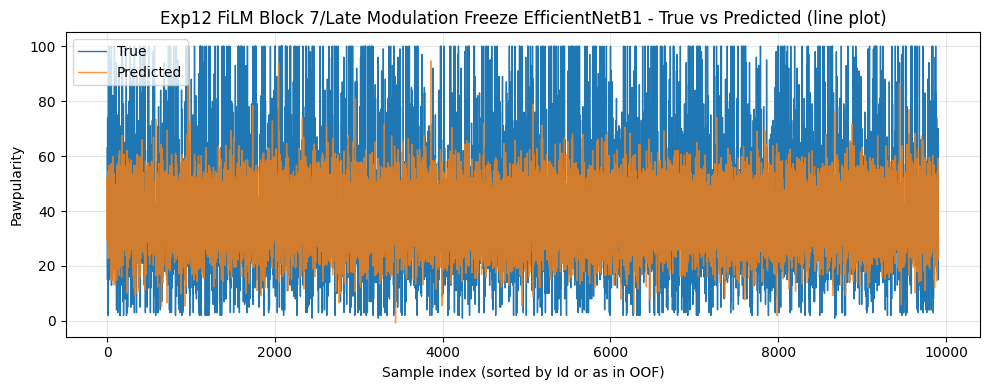

In [10]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM Block 7/Late Modulation Freeze EfficientNetB1")





In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12 FiLM Block 7/Late Modulation FreezeEfficientNetB1",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/exp4/oof_detail.csv'

In [ ]:
df_bins.head()

,bin,count,Exp12 FiLM Block 7/Late Modulation FreezeEfficientNetB1_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.102808,23.561754,0.458946,Exp12 FiLM Block 7/Late Modulation FreezeEffic...
1,"(20, 40]",5119,12.176327,11.605182,-0.571146,Exp4_FeatureConcat EffB1 Fusion_better
2,"(40, 60]",2088,19.353926,16.538259,-2.815666,Exp4_FeatureConcat EffB1 Fusion_better
3,"(60, 80]",727,36.062527,30.127592,-5.934935,Exp4_FeatureConcat EffB1 Fusion_better
4,"(80, 100]",561,58.749096,46.623998,-12.125098,Exp4_FeatureConcat EffB1 Fusion_better


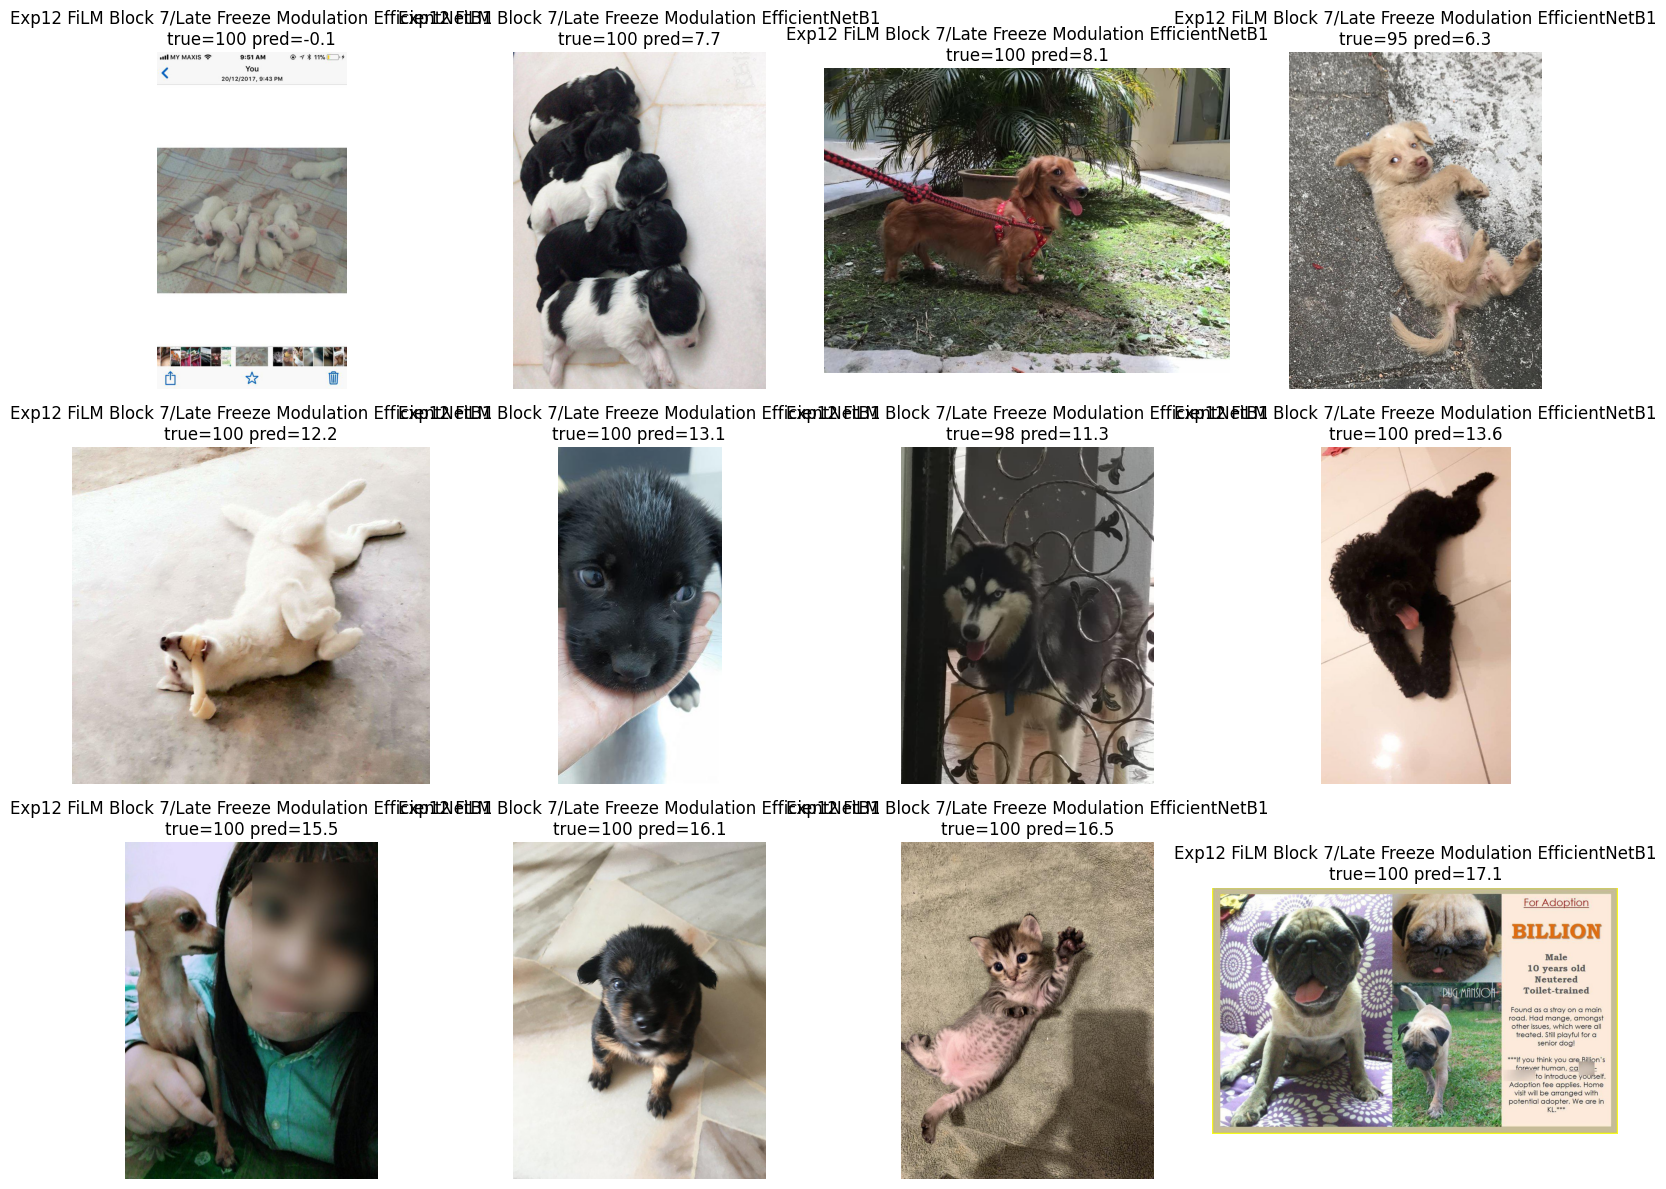

In [ ]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12 FiLM Block 7/Late Freeze Modulation EfficientNetB1")

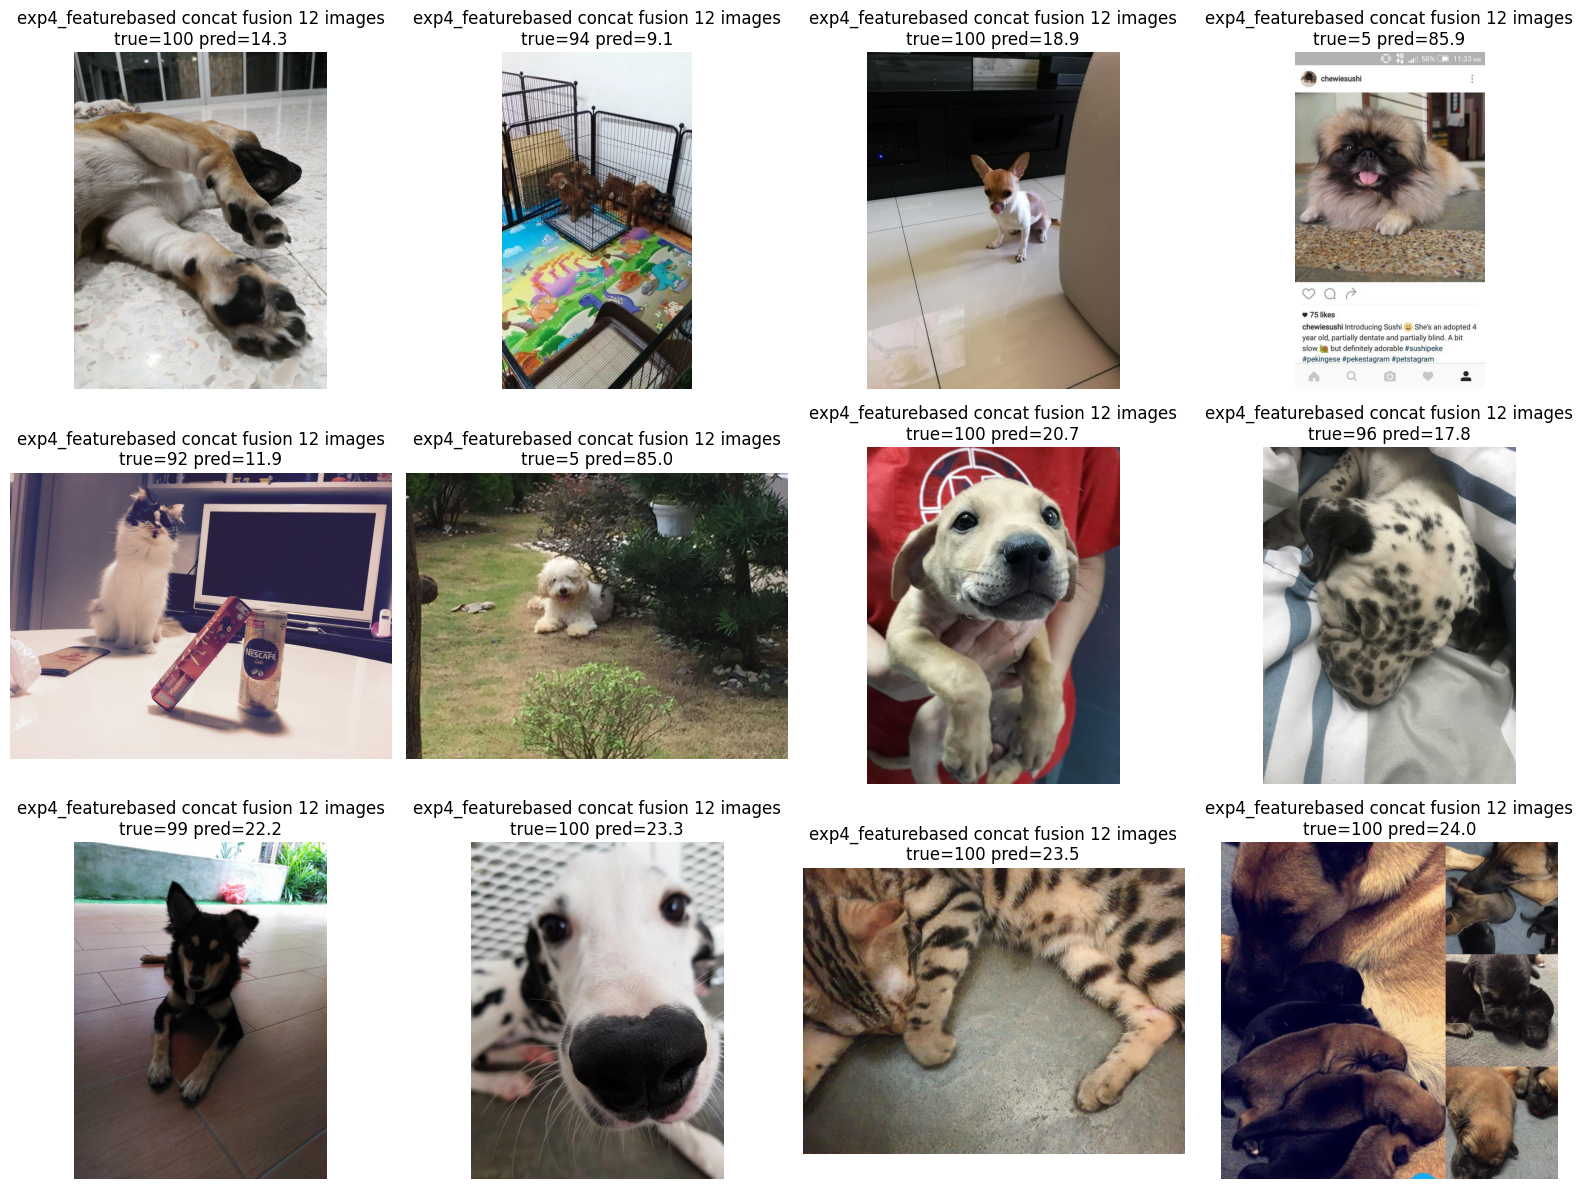

In [ ]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")